### Ferritin Prediction

### Dataset Examination (Veri Setinin İncelenmesi)

In [ ]:
#Kutuphanelerin Dahil Edilmesi
import numpy as np
import pandas as pd
import random

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import shap
import itertools
import plotly.graph_objects as go
import plotly.express as px
%matplotlib inline

from joblib import dump, load

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, validation_curve
from sklearn.model_selection import KFold
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import KNNImputer

import tensorflow as tf
from tensorflow import keras

from keras import metrics
from tensorflow.keras.layers import Dense, Activation, Dropout, BatchNormalization, Input, ReLU, LeakyReLU, PReLU
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.metrics import MeanSquaredError, RootMeanSquaredError, MeanAbsoluteError
from tensorflow.keras.activations import linear

from keras_tuner import RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters

import warnings
warnings.filterwarnings("ignore")

random.seed(17)
np.random.seed(17)
tf.random.set_seed(17)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [ ]:
#Veri Setinin Okunmasi
df = pd.read_excel("ferritin_data.xlsx")
df.drop('No', axis=1, inplace=True)
#df.drop('Ferritin Level', axis=1, inplace=True)
data = df.copy()

In [ ]:
# Veri Setine Genel Bakis icin Fonksiyonlar
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(head))
    print("##################### Tail #####################")
    print(dataframe.tail(head))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T)

def cat_summary(dataframe, col_name, plot=False):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")
    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show(block=True)

def num_summary(dataframe, numerical_col, plot=False):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        dataframe[numerical_col].hist(bins=20)
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)

def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")

def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean()}), end="\n\n\n")

def plot_target_summary_with_cat(dataframe, target, categorical_col):
    mean_values = dataframe.groupby(categorical_col)[target].mean().reset_index()
    fig = px.bar(mean_values, x=categorical_col, y=target, title=f'{categorical_col} - {target} (Mean)',
                 color=categorical_col, color_discrete_sequence=px.colors.qualitative.Set2)
    fig.update_layout(bargap=0.2)
    fig.show()

def correlation_matrix(df, cols):
    fig = plt.gcf()
    fig.set_size_inches(10, 8)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    fig = sns.heatmap(df[cols].corr(), annot=True, linewidths=0.5, annot_kws={'size': 12}, linecolor='w', cmap='RdBu')
    plt.show(block=True)

def grab_col_names(dataframe, cat_th=15, car_th=20):
    """

    Veri setindeki kategorik, numerik ve kategorik fakat kardinal değişkenlerin isimlerini verir.
    Not: Kategorik değişkenlerin içerisine numerik görünümlü kategorik değişkenler de dahildir.

    Parameters
    ------
        dataframe: dataframe
                Değişken isimleri alınmak istenilen dataframe
        cat_th: int, optional
                numerik fakat kategorik olan değişkenler için sınıf eşik değeri
        car_th: int, optinal
                kategorik fakat kardinal değişkenler için sınıf eşik değeri

    Returns
    ------
        cat_cols: list
                Kategorik değişken listesi
        num_cols: list
                Numerik değişken listesi
        cat_but_car: list
                Kategorik görünümlü kardinal değişken listesi

    Examples
    ------
        import seaborn as sns
        df = sns.load_dataset("iris")
        print(grab_col_names(df))


    Notes
    ------
        cat_cols + num_cols + cat_but_car = toplam değişken sayısı
        num_but_cat cat_cols'un içerisinde.
        Return olan 3 liste toplamı toplam değişken sayısına eşittir: cat_cols + num_cols + cat_but_car = değişken sayısı

    """

    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                   dataframe[col].dtypes != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                   dataframe[col].dtypes == "O"]
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # num_cols
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # print(f"Observations: {dataframe.shape[0]}")
    # print(f"Variables: {dataframe.shape[1]}")
    # print(f'cat_cols: {len(cat_cols)}')
    # print(f'num_cols: {len(num_cols)}')
    # print(f'cat_but_car: {len(cat_but_car)}')
    # print(f'num_but_cat: {len(num_but_cat)}')
    return cat_cols, num_cols, cat_but_car

In [ ]:
#Veri Setindeki ilk 10 veriye goz atma
df.head(n=10)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
0,50,Kadın,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21,Kadın,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27,Kadın,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23,Kadın,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49,Kadın,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1
5,47,Kadın,7.20000,61.60000,25.70000,6.60000,10.70000,17.30000,18.70000,2.70000,1
6,47,Kadın,6.50000,66.10000,24.80000,5.45000,9.90000,17.30000,23.60000,2.80000,1
7,31,Kadın,8.50000,64.30000,30.50000,7.27000,9.70000,17.90000,19.10000,2.90000,1
8,29,Kadın,8.20000,65.30000,31.40000,7.87000,9.60000,17.00000,20.30000,3.00000,1
9,44,Kadın,5.80000,59.70000,22.40000,6.67000,9.80000,15.50000,21.20000,3.00000,1


In [ ]:
#Veri Setindeki son 10 veriye goz atma
df.tail(n=10)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
7190,81,Kadın,12.00000,95.00000,38.30000,9.17000,11.80000,29.80000,13.40000,391.00000,0
7191,53,Erkek,14.60000,89.20000,44.40000,8.87000,9.00000,29.30000,12.00000,394.00000,0
7192,55,Erkek,14.90000,94.20000,45.80000,6.03000,12.20000,30.70000,13.90000,395.00000,0
7193,45,Erkek,15.30000,91.20000,44.70000,7.71000,10.60000,31.20000,11.80000,395.00000,0
7194,54,Erkek,15.00000,89.20000,44.00000,9.23000,10.00000,30.40000,12.40000,396.00000,0
7195,67,Kadın,14.90000,87.60000,44.70000,8.60000,10.90000,29.20000,11.70000,397.00000,0
7196,60,Erkek,16.90000,89.90000,49.90000,7.61000,10.50000,30.50000,13.20000,398.00000,0
7197,74,Erkek,13.50000,93.40000,40.80000,7.41000,10.50000,30.90000,13.20000,398.00000,0
7198,72,Erkek,12.10000,96.10000,37.30000,7.14000,9.50000,31.20000,12.90000,399.00000,0
7199,28,Erkek,16.30000,82.10000,48.60000,6.64000,10.40000,27.50000,12.30000,399.00000,0


In [ ]:
#Veri setinin satir, sutun sayısı
print("################ Shape ################ ")
print(df.shape)
print("Gozlem (n) sayisi:", len(df.index))
print("Degisken (variable) sayisi:",len(df.columns))

################ Shape ################ 
(7200, 11)
Gozlem (n) sayisi: 7200
Degisken (variable) sayisi: 11


In [ ]:
#Verilen Tipleri (Data Types)
print("################ Data Types ################")
df['Yaş'] = df['Yaş'].astype('float64')
df.dtypes

################ Data Types ################


Yaş                   float64
Cinsiyet               object
HGB (12-16)           float64
MCV (81-101)          float64
HCT (36-44)           float64
WBC (4.5-10)          float64
MPV (9-12)            float64
MCH (27-35)           float64
RDW-CV (11.5-14.5)    float64
Ferritin (30-400)     float64
Ferritin Level          int64
dtype: object

In [ ]:
# Eksik verilere (Missing Value) bakma
print("################ Missing Values ################")
df.isnull().sum()

################ Missing Values ################


Yaş                   0
Cinsiyet              0
HGB (12-16)           0
MCV (81-101)          0
HCT (36-44)           0
WBC (4.5-10)          0
MPV (9-12)            0
MCH (27-35)           0
RDW-CV (11.5-14.5)    0
Ferritin (30-400)     0
Ferritin Level        0
dtype: int64

In [ ]:
#Kategorik ve Numerik Degiskenleri Yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)

In [ ]:
# Toplam Degisken Sayisi
print("Toplam degisken sayisi:", len(cat_cols+num_cols+cat_but_car))

# kac adet kategorik degisken var
print("Kategorik degisken sayisi:", len(cat_cols))

# kac adet numerik degisken var
print("Numerik degisken sayisi:", len(num_cols))

# kac adet kategorik olan ama kardinal degisken var
print("Kategorik ama kardinal gorunen degisken sayisi:", len(cat_but_car))

Toplam degisken sayisi: 11
Kategorik degisken sayisi: 2
Numerik degisken sayisi: 9
Kategorik ama kardinal gorunen degisken sayisi: 0


In [ ]:
#Kategorik degiskenlerin icindeki tekil (unique) verileri bulma
for col in df.columns:
    values = []

    # numerik olmayanlar -> kategorik
    if col == 'Cinsiyet' or col == 'Ferritin Level':
        for val in df[col].unique():
            values.append(val)

        print("{0} -> {1}".format(col, values))

Cinsiyet -> ['Kadın', 'Erkek']
Ferritin Level -> [1, 0]


In [ ]:
# Numerik degiskenlerin icindeki tekil (unique) verileri bulma
for col in df.columns:
    values = []

    # kategorik olmayanlar -> numerik
    if col in df.describe().columns and col != 'Ferritin Level':
        for val in df[col].unique():
            values.append(val)

        print("{0} -> {1} ...".format(col, values[:5]))

Yaş -> [50.0, 21.0, 27.0, 23.0, 49.0] ...
HGB (12-16) -> [6.5, 9.1, 7.9, 6.7, 6.9] ...
MCV (81-101) -> [61.1, 71.9, 63.1, 59.9, 64.0] ...
HCT (36-44) -> [26.1, 31.7, 29.4, 24.3, 25.2] ...
WBC (4.5-10) -> [5.36, 3.79, 5.24, 3.12, 7.55] ...
MPV (9-12) -> [10.2, 11.6, 10.1, 9.1, 10.7] ...
MCH (27-35) -> [15.2, 20.6, 17.0, 16.5, 17.5] ...
RDW-CV (11.5-14.5) -> [19.3, 16.2, 20.7, 20.9, 18.8] ...
Ferritin (30-400) -> [2.2, 2.3, 2.4, 2.6, 2.7] ...


In [ ]:
# her sutun icindeki tekil (unique) veri adedine bakma
for col in df.columns:
    print(col, df[col].nunique())

Yaş 80
Cinsiyet 2
HGB (12-16) 136
MCV (81-101) 406
HCT (36-44) 313
WBC (4.5-10) 676
MPV (9-12) 67
MCH (27-35) 198
RDW-CV (11.5-14.5) 135
Ferritin (30-400) 1156
Ferritin Level 2


In [ ]:
#Genel Bilgiler
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Yaş                 7200 non-null   float64
 1   Cinsiyet            7200 non-null   object 
 2   HGB (12-16)         7200 non-null   float64
 3   MCV (81-101)        7200 non-null   float64
 4   HCT (36-44)         7200 non-null   float64
 5   WBC (4.5-10)        7200 non-null   float64
 6   MPV (9-12)          7200 non-null   float64
 7   MCH (27-35)         7200 non-null   float64
 8   RDW-CV (11.5-14.5)  7200 non-null   float64
 9   Ferritin (30-400)   7200 non-null   float64
 10  Ferritin Level      7200 non-null   int64  
dtypes: float64(9), int64(1), object(1)
memory usage: 618.9+ KB


In [ ]:
# Numerik degiskenlerin incelenmesi
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Yaş,7200.00000,46.74222,18.16979,18.00000,31.00000,46.00000,61.00000,102.00000
HGB (12-16),7200.00000,13.49181,1.84875,4.50000,12.40000,13.50000,14.60000,19.50000
MCV (81-101),7200.00000,87.90182,6.04394,58.10000,84.90000,88.60000,91.60000,125.30000
HCT (36-44),7200.00000,41.58249,4.80125,17.00000,38.80000,41.60000,44.60000,57.90000
WBC (4.5-10),7200.00000,7.03748,1.47657,1.30000,5.97000,7.02000,8.12000,9.99000
MPV (9-12),7200.00000,10.57585,0.92413,7.90000,9.90000,10.50000,11.20000,14.80000
MCH (27-35),7200.00000,28.49978,2.66938,15.20000,27.30000,29.00000,30.20000,46.30000
RDW-CV (11.5-14.5),7200.00000,13.75500,1.77256,10.40000,12.60000,13.20000,14.30000,26.50000
Ferritin (30-400),7200.00000,56.02671,62.74846,2.20000,16.30000,29.95000,72.00000,399.00000


In [ ]:
# Numerik degiskenlerin incelenmesi - Aykiri Deger Tespiti icin On Bakis
df[num_cols].quantile([0, 0.05, 0.50, 0.95, 0.99, 1]).T

,0.00000,0.05000,0.50000,0.95000,0.99000,1.00000
Yaş,18.00000,20.95000,46.00000,78.00000,86.00000,102.00000
HGB (12-16),4.50000,10.40000,13.50000,16.50000,17.60000,19.50000
MCV (81-101),58.10000,77.00000,88.60000,96.20000,100.50000,125.30000
HCT (36-44),17.00000,33.80000,41.60000,49.40000,52.10100,57.90000
WBC (4.5-10),1.30000,4.61000,7.02000,9.46050,9.87000,9.99000
MPV (9-12),7.90000,9.20000,10.50000,12.20000,13.00000,14.80000
MCH (27-35),15.20000,23.30000,29.00000,31.90000,33.30000,46.30000
RDW-CV (11.5-14.5),10.40000,12.00000,13.20000,17.20000,20.50000,26.50000
Ferritin (30-400),2.20000,7.40000,29.95000,192.05000,306.07000,399.00000


In [ ]:
# Kategorik degiskenlerin incelenmesi
for col in cat_cols:
  cat_summary(df, col)

          Cinsiyet    Ratio
Cinsiyet                   
Kadın         5240 72.77778
Erkek         1960 27.22222
##########################################
                Ferritin Level    Ratio
Ferritin Level                         
1                         3600 50.00000
0                         3600 50.00000
##########################################


In [ ]:
#Kategorik ve Numerik Degiskenleri Yeniden Yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)

In [ ]:
#Veri setindeki 5 ilk bes veriye goz atma
df.head(n=5)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
0,50.00000,Kadın,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21.00000,Kadın,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27.00000,Kadın,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23.00000,Kadın,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49.00000,Kadın,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1


Dolayısı ile veriseti icinde:

 - Toplam **7200 gozlem birimi** var.
 - Toplam **11 degisken** var:
  - **9 degisken** numerik
  - **2 degisken** kategorik
  - ##############################
  - **9 bagimsiz degisken:** 'Yaş', 'Cinsiyet', 'HGB (12-16)', 'MCV (81-101)', 'HCT (36-44)'', 'WBC (4.5-10)', 'MPV (9-12)', 'MCH (27-35)', 'RDW-CV (11.5-14.5)'
  - **2 bagimli degisken:** 'Ferritin (30-400)', 'Ferritin Level'

### Data Preprocessing (Veri Ön İşleme)

#### Outlier Analysis/Detection (Aykiri Deger Analizi)

In [ ]:
def outlier_thresholds(dataframe, col_name, q1=0.05, q3=0.95):
    quartile1 = dataframe[col_name].quantile(q1)
    quartile3 = dataframe[col_name].quantile(q3)
    interquantile_range = quartile3 - quartile1
    up_limit = quartile3 + 1.5 * interquantile_range
    low_limit = quartile1 - 1.5 * interquantile_range
    return low_limit, up_limit

def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

def check_outlier(dataframe, col_name, q1=0.05, q3=0.95):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name, q1, q3)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

def grab_outliers(dataframe, col_name, index=False):
    low, up = outlier_thresholds(dataframe, col_name)

    if dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].shape[0] > 10:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].head())
    else:
        print(dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))])

    if index:
        outlier_index = dataframe[((dataframe[col_name] < low) | (dataframe[col_name] > up))].index
        return outlier_index

def remove_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    df_without_outliers = dataframe[~((dataframe[col_name] < low_limit) | (dataframe[col_name] > up_limit))]
    return df_without_outliers

In [ ]:
#Aykiri Deger Analizi -> Verilen araliklar disinda kalanaykiri degerler yok
for col in ['Yaş','HGB (12-16)','MCV (81-101)','HCT (36-44)','WBC (4.5-10)','MPV (9-12)','MCH (27-35)','RDW-CV (11.5-14.5)']:
    print(col,':', check_outlier(df, col, 0.05, 0.95))

Yaş : False
HGB (12-16) : False
MCV (81-101) : True
HCT (36-44) : False
WBC (4.5-10) : False
MPV (9-12) : False
MCH (27-35) : True
RDW-CV (11.5-14.5) : True


In [ ]:
# Baskılama Yöntemi (re-assignment with thresholds) ile 'MCV (81-101)','MCH (27-35)', 'RDW-CV (11.5-14.5)' degiskenleri baskilandi.
for col in ['MCV (81-101)','MCH (27-35)','RDW-CV (11.5-14.5)']:
    replace_with_thresholds(df, col)

In [ ]:
#Aykiri Deger Analizi -> Verilen araliklar disinda kalan aykiri degerler yok
for col in ['Yaş','HGB (12-16)','MCV (81-101)','HCT (36-44)','WBC (4.5-10)','MPV (9-12)','MCH (27-35)','RDW-CV (11.5-14.5)']:
    print(col,':', check_outlier(df, col, 0.05, 0.95))

Yaş : False
HGB (12-16) : False
MCV (81-101) : False
HCT (36-44) : False
WBC (4.5-10) : False
MPV (9-12) : False
MCH (27-35) : False
RDW-CV (11.5-14.5) : False


#### Detection and Imputation of Missing Values (Kayıp/Eksik Verilerin Tespiti ve Giderilmesi)

In [ ]:
def missing_values_table(dataframe, na_name=False):
    na_columns = [col for col in dataframe.columns if dataframe[col].isnull().sum() > 0]

    n_miss = dataframe[na_columns].isnull().sum().sort_values(ascending=False)
    ratio = (dataframe[na_columns].isnull().sum() / dataframe.shape[0] * 100).sort_values(ascending=False)
    missing_df = pd.concat([n_miss, np.round(ratio, 2)], axis=1, keys=['n_miss', 'ratio'])
    print(missing_df, end="\n")

    if na_name:
        return na_columns

missing_values_table(df) # Veri setinde eksik değer yok.

Empty DataFrame
Columns: [n_miss, ratio]
Index: []


In [ ]:
#Kategorik ve Numerik Degiskenleri Yeniden Yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)

df.head(n=5)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
0,50.00000,Kadın,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21.00000,Kadın,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27.00000,Kadın,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23.00000,Kadın,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49.00000,Kadın,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1


In [ ]:
#Kategorik ve numerik degiskenleri yeniden yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)
print('Kategorik Degiskenler:',cat_cols)
print('Numerik Degiskenler:',num_cols)
df.info()

Kategorik Degiskenler: ['Cinsiyet', 'Ferritin Level']
Numerik Degiskenler: ['Yaş', 'HGB (12-16)', 'MCV (81-101)', 'HCT (36-44)', 'WBC (4.5-10)', 'MPV (9-12)', 'MCH (27-35)', 'RDW-CV (11.5-14.5)', 'Ferritin (30-400)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7200 entries, 0 to 7199
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Yaş                 7200 non-null   float64
 1   Cinsiyet            7200 non-null   object 
 2   HGB (12-16)         7200 non-null   float64
 3   MCV (81-101)        7200 non-null   float64
 4   HCT (36-44)         7200 non-null   float64
 5   WBC (4.5-10)        7200 non-null   float64
 6   MPV (9-12)          7200 non-null   float64
 7   MCH (27-35)         7200 non-null   float64
 8   RDW-CV (11.5-14.5)  7200 non-null   float64
 9   Ferritin (30-400)   7200 non-null   float64
 10  Ferritin Level      7200 non-null   int64  
dtypes: float64(9), int64(1), object(1)

#### Feature Engineering (Ozellik Muhendisligi) -> Optional

In [ ]:
# # Yeni Degiskenlerin Olusturulmasi
#
# # MPV
# df['New_MPV (9-12)'] = pd.cut(x=df['MPV (9-12)'], bins=[9, 10.5, 11.001, 12.5], labels=["Low", "Mid","High"])
#
# # MCH
# df['New_MCH (27-35'] = pd.cut(x=df['MCH (27-35)'], bins=[27, 30, 35.001, 36], labels =["Low", "Mid","High"])
#
# #Kategorik ve Numerik Degiskenleri Yeniden Yakalama
# cat_cols, num_cols, cat_but_car = grab_col_names(df)
#
# #Kategorik ve Numerik Degiskenlerin Ekrana Yazidirilmasi
#
# print('Kategorik Degiskenler:',cat_cols)
# print('Numerik Degiskenler:',num_cols)
# df[cat_cols] = df[cat_cols].astype('object')
# df.head(n=5)

In [ ]:
# # Türetilen Kategorik Degiskenlerin Incelenmesi
# for col in ['New_MPV (9-12)','New_MCH (27-35']:
#    cat_summary(df, col)

#### Rare kategoriler ile bagimli degisken arasındaki iliskinin analiz edilmesi

In [ ]:
# Rare_analyzer fonksiyonunun ile degiskenlerin analizi
def rare_analyser(dataframe, target, cat_cols):
    for col in cat_cols:
        print(col, ":", len(dataframe[col].value_counts()))
        print(pd.DataFrame({"COUNT": dataframe[col].value_counts(),
                            "RATIO": dataframe[col].value_counts() / len(dataframe),
                            "TARGET_MEAN": dataframe.groupby(col)[target].mean()}), end="\n\n\n")

rare_analyser(df, "Ferritin (30-400)", cat_cols)

Cinsiyet : 2
          COUNT   RATIO  TARGET_MEAN
Cinsiyet                            
Erkek      1960 0.27222     96.81760
Kadın      5240 0.72778     40.76905


Ferritin Level : 2
                COUNT   RATIO  TARGET_MEAN
Ferritin Level                            
0                3600 0.50000     95.38111
1                3600 0.50000     16.67231




In [ ]:
# Rare_encoder fonksiyonunun yazilmasi
def rare_encoder(dataframe, rare_perc):
    temp_df = dataframe.copy()

    rare_columns = [col for col in temp_df.columns if temp_df[col].dtypes == 'O'
                    and (temp_df[col].value_counts() / len(temp_df) < rare_perc).any(axis=None)]

    for var in rare_columns:
        tmp = temp_df[var].value_counts() / len(temp_df)
        rare_labels = tmp[tmp < rare_perc].index
        temp_df[var] = np.where(temp_df[var].isin(rare_labels), 'Rare', temp_df[var])

    return temp_df

# Kategoriler analiz edildi, Cinsiyet ve Ferritin degiskeninde birlestirme yapilmadi..
df = rare_encoder(df, 0.01)

# Rare_analyzer fonksiyonunun ile degiskenlerin analizi
rare_analyser(df, "Ferritin (30-400)", cat_cols)

Cinsiyet : 2
          COUNT   RATIO  TARGET_MEAN
Cinsiyet                            
Erkek      1960 0.27222     96.81760
Kadın      5240 0.72778     40.76905


Ferritin Level : 2
                COUNT   RATIO  TARGET_MEAN
Ferritin Level                            
0                3600 0.50000     95.38111
1                3600 0.50000     16.67231




In [ ]:
df.head(n=5)

,Yaş,Cinsiyet,HGB (12-16),MCV (81-101),HCT (36-44),WBC (4.5-10),MPV (9-12),MCH (27-35),RDW-CV (11.5-14.5),Ferritin (30-400),Ferritin Level
0,50.00000,Kadın,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21.00000,Kadın,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27.00000,Kadın,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23.00000,Kadın,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49.00000,Kadın,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1


#### One-Hot Encoding (Kategorik Verilerin Donusturulmesi)

In [ ]:
#Cinsiyet degiskeninin sayisal veriye donusturulmesi Kadin -> 0, Erkek -> 1
df["Cinsiyet"] = df["Cinsiyet"].map({"Kadın": 0, "Erkek": 1}).astype("float64")

#Sutun isimlerini degistirme
df.columns = ['Age', 'Sex', 'HGB', 'MCV', 'HCT', 'WBC', 'MPV', 'MCH', 'RDW-CV', 'Ferritin', 'Ferritin_Level']
#Kategorik ve Numerik Degiskenleri Yeniden Yakalama
cat_cols, num_cols, cat_but_car = grab_col_names(df)

print('Kategorik Degiskenler:', cat_cols)
print('#####################')
print('Numerik Degiskenler:',num_cols)

Kategorik Degiskenler: ['Sex', 'Ferritin_Level']
#####################
Numerik Degiskenler: ['Age', 'HGB', 'MCV', 'HCT', 'WBC', 'MPV', 'MCH', 'RDW-CV', 'Ferritin']


In [ ]:
df.head(n=5)

,Age,Sex,HGB,MCV,HCT,WBC,MPV,MCH,RDW-CV,Ferritin,Ferritin_Level
0,50.00000,0.00000,6.50000,61.10000,26.10000,5.36000,10.20000,15.20000,19.30000,2.20000,1
1,21.00000,0.00000,9.10000,71.90000,31.70000,3.79000,11.60000,20.60000,16.20000,2.30000,1
2,27.00000,0.00000,7.90000,63.10000,29.40000,5.24000,10.10000,17.00000,20.70000,2.40000,1
3,23.00000,0.00000,6.70000,59.90000,24.30000,3.12000,9.10000,16.50000,20.90000,2.40000,1
4,49.00000,0.00000,6.90000,64.00000,25.20000,7.55000,10.70000,17.50000,18.80000,2.60000,1


####  Feature Vector and Target Variable (Bagimsiz Degiskenler ve Bagimli Degisken)

In [ ]:
X = df.drop(['Ferritin', 'Ferritin_Level'], axis=1) # Bagimsiz Degiskenler
y = df['Ferritin'] # Bagimli Degisken

(X.shape, y.shape)

((7200, 9), (7200,))

#### Train-Test Split (Egitim-Test Veri Setlerinin Ayrilmasi)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 17)

# X_train ve X_test sekilleri

X_train.shape, X_test.shape

((5040, 9), (2160, 9))

#### Feature Scaling (Oznitelik Olceklendirilmesi)

In [ ]:
#Standard Scaler kullanılmasi
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Sayisal degiskenlerin belirlenmesi (one-hot encoding sonrası kategorikler disarida birakildi
numeric_columns = ['Age', 'HGB', 'MCV', 'HCT', 'WBC', 'MPV', 'MCH', 'RDW-CV']

# Sayısal degiskenlerin secilmesi
X_train_numeric = X_train[numeric_columns]
X_test_numeric = X_test[numeric_columns]

X_train_encoded = X_train.drop(columns=numeric_columns)
X_test_encoded = X_test.drop(columns=numeric_columns)

X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)
X_test_numeric_scaled = scaler.transform(X_test_numeric)

# DataFrame olarak geri donusturulmesi (İndeks ve sütun isimlerini koruyarak)
X_train_numeric_scaled = pd.DataFrame(X_train_numeric_scaled, columns=numeric_columns, index=X_train.index)
X_test_numeric_scaled = pd.DataFrame(X_test_numeric_scaled, columns=numeric_columns, index=X_test.index)

# Sayisal ve one-hot encoded verileri birlestirelim
X_train = pd.concat([X_train_numeric_scaled, X_train_encoded], axis=1)
X_test = pd.concat([X_test_numeric_scaled, X_test_encoded], axis=1)

In [ ]:
#Min Max Scaler kullanılmasi -> Alternatif olarak
#from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler()

#numeric_columns = X_train.select_dtypes(include=['int64', 'float64']).columns

#X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
#X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

In [ ]:
#X_train veri setinde ilk 5 veriye goz atma
X_train.head(n=5)

,Age,HGB,MCV,HCT,WBC,MPV,MCH,RDW-CV,Sex
874,-0.25889,-0.09877,-0.74955,0.09017,1.76254,0.25564,-0.77928,0.18354,0.00000
3908,-0.42470,1.02592,0.82271,1.03737,-1.42441,-1.48520,0.83713,-0.53894,1.00000
6123,0.29379,0.81169,0.26000,1.03737,-0.49656,-0.83238,0.12290,-0.81681,1.00000
6154,0.07271,0.49035,0.62411,0.83146,-0.24107,-0.72358,0.16049,-0.65009,0.00000
4685,0.79120,-0.04521,-0.03790,0.17254,-1.26977,1.23487,-0.29060,-0.20549,0.00000


In [ ]:
#X_test veri setinde ilk 5 veriye goz atma
X_test.head(n=5)

,Age,HGB,MCV,HCT,WBC,MPV,MCH,RDW-CV,Sex
3622,-0.14836,0.81169,-0.25305,0.41963,-1.43786,0.47325,0.46122,-0.76124,0.00000
5407,0.84647,-0.36655,0.64066,-0.54816,-0.07970,-0.39717,0.64918,-0.42779,0.00000
5345,1.01227,0.65102,-0.40200,0.95501,0.60610,-0.50597,-0.47856,-0.65009,0.00000
1475,-0.14836,-0.47367,0.45861,-0.38343,-0.69155,0.14684,0.12290,-0.37221,0.00000
4225,1.56495,-0.47367,0.69031,-0.32165,-0.46295,1.34367,0.19808,-0.48336,0.00000


In [ ]:
#y_train veri setinde ilk 5 veriye goz atma
y_train.head(n=5)

874     10.60000
3908    34.40000
6123   108.00000
6154   110.00000
4685    50.70000
Name: Ferritin, dtype: float64

In [ ]:
#y_test veri setinde ilk 5 veriye goz atma
y_test.head(n=5)

3622   30.30000
5407   72.40000
5345   70.40000
1475   14.30000
4225   40.90000
Name: Ferritin, dtype: float64

In [ ]:
# Train ve test veri setinin kopyasinin alinmasi
X2 = X.copy()
y2 = y.copy()
X_train2 = X_train.copy()
X_test2 = X_test.copy()
y_train2 = y_train.copy()
y_test2 = y_test.copy()

### Artificial Neural Networks (ANN) with Feature Selection

In [ ]:
print("Keras Current Version:", keras.__version__, "Tensorflow Current Version:", tf.__version__)

# if (Keras Current Version < 3.3.3) and (Tensorflow Current Version < 2.16.1)

# !pip uninstall tf-keras
# !pip install keras-tuner
# !pip install tensorflow==2.17.0

Keras Current Version: 3.11.3 Tensorflow Current Version: 2.17.0


#### Data Preparation

In [ ]:
def prepare_datasets(X_train, X_val, y_train, y_val, batch_size=None):
    if batch_size is None:
        batch_size = len(X_train)
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_dataset = train_dataset.shuffle(buffer_size=len(X_train)).batch(batch_size)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
    val_dataset = val_dataset.batch(batch_size)
    return train_dataset, val_dataset

def plot_training_history_classification(history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy'):

    #Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_loss], label='Training Loss')
    plt.plot(history.history[val_loss], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Metrics
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f"Training: {train_metric}")
    plt.plot(history.history[val_metric], label=f"Validation: {val_metric}")
    plt.title(f'Training and Validation {train_metric} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(f'train_metric')
    plt.legend()
    plt.show()

def plot_training_history_regression(history, train_loss='loss', train_metric='mean_absolute_error', val_loss='val_loss', val_metric='val_mean_absolute_error'):

    # Loss (MSE, MAE, etc.)
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_loss], label='Training Loss')
    plt.plot(history.history[val_loss], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Metric (MAE, MSE, etc.)
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f"Training: {train_metric.replace('_', ' ').capitalize()}")
    plt.plot(history.history[val_metric], label=f"Validation: {val_metric.replace('_', ' ').capitalize()}")
    plt.title(f'Training and Validation {train_metric.replace('_', ' ').capitalize()} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(f'{train_metric.replace('_', ' ').capitalize()}')
    plt.legend()
    plt.show()

def get_best_epoch_details(history, metric="val_loss", mode=min):
    metric_values = history.history[metric]
    min_metric_value_index = metric_values.index(mode(metric_values))
    best_epoch = min_metric_value_index + 1

    metrics = []
    values = []

    for key, value in history.history.items():
        metrics.append(key)
        values.append(value[min_metric_value_index])

    data = {'Metric': metrics, 'Value': values}
    df = pd.DataFrame(data)
    df['Value'] = df['Value'].map('{:.4f}'.format)
    best_epoch_data = pd.DataFrame({'Metric': ['best_epoch'], 'Value': [str(best_epoch)]})
    df = pd.concat([df, best_epoch_data], ignore_index=True)
    return df

def print_hyperparameters(hyperparameters):
    hp_df = pd.DataFrame(list(hyperparameters.items()), columns=['Hyperparameter', 'Value'])
    print(hp_df)

In [ ]:
# Preparation of datasets
train_ds, val_ds = prepare_datasets(X_train, X_test, y_train, y_test, batch_size=32)

#### Base Model

In [ ]:
base_model = Sequential([
    Input(shape=(train_ds.element_spec[0].shape[1],)),

    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='linear')])

In [ ]:
optimizer = Adam(learning_rate=0.001)

base_model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=[MeanSquaredError(), RootMeanSquaredError(), MeanAbsoluteError()])

In [ ]:
early_stopping = EarlyStopping(
                    monitor='val_mean_squared_error',
                    patience=25,
                    verbose=1,
                    restore_best_weights=True,
                    mode="min")

In [ ]:
base_model_history = base_model.fit(train_ds,
                                    epochs=500,
                                    validation_data=val_ds,
                                    verbose=1,
                                    callbacks=early_stopping)

Epoch 1/500
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6246.1416 - mean_absolute_error: 54.9915 - mean_squared_error: 6245.5938 - root_mean_squared_error: 79.0291 - val_loss: 6092.1763 - val_mean_absolute_error: 54.2323 - val_mean_squared_error: 6091.6133 - val_root_mean_squared_error: 78.0488
Epoch 2/500
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5011.7310 - mean_absolute_error: 50.6654 - mean_squared_error: 5011.1489 - root_mean_squared_error: 70.7895 - val_loss: 4745.1118 - val_mean_absolute_error: 46.7792 - val_mean_squared_error: 4744.5132 - val_root_mean_squared_error: 68.8804
Epoch 3/500
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4031.7476 - mean_absolute_error: 42.9656 - mean_squared_error: 4031.1313 - root_mean_squared_error: 63.4912 - val_loss: 3359.2346 - val_mean_absolute_error: 36.1076 - val_mean_squared_error: 3358.5984 - val_root_mean_squared_error: 57.9534
Epoch 4/500
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3210.7664 - mean_absolute_error: 34.

In [ ]:
get_best_epoch_details(base_model_history, metric="val_mean_squared_error", mode=min)

,Metric,Value
0,loss,2763.4888
1,mean_absolute_error,33.5731
2,mean_squared_error,2762.7207
3,root_mean_squared_error,52.5616
4,val_loss,2617.3521
5,val_mean_absolute_error,32.1509
6,val_mean_squared_error,2616.5708
7,val_root_mean_squared_error,51.1524
8,best_epoch,8


In [ ]:
#plot_training_history_regression(base_model_history)

In [ ]:
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 515,589 (1.97 MB)

 Trainable params: 171,265 (669.00 KB)

 Non-trainable params: 1,792 (7.00 KB)

 Optimizer params: 342,532 (1.31 MB)

In [ ]:
def evaluate_model(val_ds, model,return_values=False):
    predictions = []
    true_values = []

    for features, labels in val_ds:
        batch_predictions = model.predict(features, verbose=0)
        predictions.extend(batch_predictions.flatten())
        true_values.extend(labels.numpy().flatten())

    predictions = np.array(predictions)
    true_values = np.array(true_values)

    #r2 = r2_score(true_values, predictions)
    mae = mean_absolute_error(true_values, predictions)
    mse = mean_squared_error(true_values, predictions)
    rmse = np.sqrt(mse)

    #print(f"R-squared (R²): {r2}")
    print(f"Mean Absolute Error: {mae}")
    print(f"Mean Squared Error: {mse}")
    print(f"Root Mean Squared Error: {rmse}")

    print("y_true_mean:", true_values.mean())
    print("y_true_std:", true_values.std())

    if return_values:
        return true_values, predictions

In [ ]:
evaluate_model(val_ds, base_model, return_values=False)

Mean Absolute Error: 32.15090797446393
Mean Squared Error: 2616.570592351363
Root Mean Squared Error: 51.15242508768634
y_true_mean: 54.60111111111111
y_true_std: 61.43901258389453


2025-11-15 18:01:00.513352: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


#### Hyperparameter Optimization

In [ ]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(train_ds.element_spec[0].shape[1],)))

    # Hidden layers with advanced activation functions, l2, Dropout
    for i in range(hp.Int('num_layers', 1, 10)):
        model.add(Dense(
            units=hp.Int('units_' + str(i + 1), min_value=32, max_value=512, step=16),
            kernel_regularizer=l2(hp.Float('l2_' + str(i + 1), min_value=0.0001, max_value=0.01, sampling='log'))
        ))

        # Activation layer choice
        activation_choice = hp.Choice('activation_' + str(i + 1), values=['relu', 'leaky_relu', 'prelu'])

        if activation_choice == 'relu':
            model.add(ReLU())
        elif activation_choice == 'leaky_relu':
            model.add(LeakyReLU(negative_slope=0.01))
        elif activation_choice == 'prelu':
            model.add(PReLU())

        model.add(BatchNormalization())

        model.add(Dropout(hp.Float('dropout_' + str(i + 1), min_value=0.0, max_value=0.5, step=0.1)))

    # Output layer with linear activation for regression
    model.add(Dense(1, activation='linear'))

    # Optimizer: Adam with tuning for beta1 and beta2
    optimizer = Adam(
        beta_1=hp.Float('beta1', min_value=0.85, max_value=0.99, step=0.01),
        beta_2=hp.Float('beta2', min_value=0.995, max_value=0.999, step=0.001)
    )

    # Compile the model with mean squared error loss for regression
    model.compile(optimizer=optimizer,
                  loss="mse",
                  metrics=[MeanSquaredError(), RootMeanSquaredError(), MeanAbsoluteError()])

    return model

In [ ]:
random_search_tuner = RandomSearch(
    build_model,
    objective='val_mean_squared_error',
    max_trials=50,
    executions_per_trial=1,
    overwrite=True)

early_stopping = EarlyStopping(
    monitor='val_mean_squared_error',
    patience=25,
    verbose=1,
    restore_best_weights=True,
    mode='min')

model_checkpoint = ModelCheckpoint(
    'ferritin_prediction_model.keras',
    monitor='val_mean_squared_error',
    verbose=0,
    save_best_only=True)

random_search_tuner.search(
    train_ds,
    epochs=500,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint])

Trial 50 Complete [00h 00m 21s]
val_mean_squared_error: 2690.89599609375

Best val_mean_squared_error So Far: 2580.199951171875
Total elapsed time: 00h 20m 51s


In [ ]:
best_hps = random_search_tuner.get_best_hyperparameters(num_trials=1)[0]

print_hyperparameters(best_hps.values)

   Hyperparameter       Value
0      num_layers           9
1         units_1          48
2            l2_1     0.00028
3    activation_1  leaky_relu
4       dropout_1     0.40000
5           beta1     0.87000
6           beta2     0.99500
7         units_2         336
8            l2_2     0.00020
9    activation_2       prelu
10      dropout_2     0.40000
11        units_3         112
12           l2_3     0.00038
13   activation_3  leaky_relu
14      dropout_3     0.10000
15        units_4         416
16           l2_4     0.00068
17   activation_4       prelu
18      dropout_4     0.10000
19        units_5         432
20           l2_5     0.00089
21   activation_5  leaky_relu
22      dropout_5     0.20000
23        units_6         304
24           l2_6     0.00270
25   activation_6       prelu
26      dropout_6     0.10000
27        units_7         160
28           l2_7     0.00019
29   activation_7       prelu
30      dropout_7     0.10000
31        units_8          32
32        

In [ ]:
#Save the best hyperparameters
dump(best_hps, 'best_hps_ferritin.joblib')

['best_hps_ferritin.joblib']

In [ ]:
best_model = random_search_tuner.get_best_models(num_models=1)[0]

In [ ]:
best_model.save('ferritin_prediction_final_model.keras')

In [ ]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 48)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 336)            │        16,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu (PReLU)                 │ (None, 336)            │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 336)            │         1,344 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 336)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 112)            │        37,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112)            │           448 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 416)            │        47,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_1 (PReLU)               │ (None, 416)            │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 416)            │         1,664 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 416)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 432)            │       180,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 432)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 432)            │         1,728 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 432)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 304)            │       131,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_re_lu_2 (PReLU)               │ (None, 304)            │           304 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 477,217 (1.82 MB)

 Trainable params: 473,473 (1.81 MB)

 Non-trainable params: 3,744 (14.62 KB)

In [ ]:
evaluate_model(val_ds, best_model,return_values=False)

Mean Absolute Error: 31.63101764677851
Mean Squared Error: 2580.199957500819
Root Mean Squared Error: 50.79566868839132
y_true_mean: 54.60111111111111
y_true_std: 61.43901258389453


2025-11-15 18:21:54.881900: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


#### Evaluate Final Tuned Model

In [ ]:
#Load the tuned model
#best_model = load_model('ferritin_prediction_final_model.keras')

In [ ]:
# Egitim veri setinde tahminler
y_pred = best_model.predict(X_test)

# Sonuclarin Egitim Veri Setinde Degerlendirilmesi
print("*********** ANN - Test Set ***********")
print("R-squared:", r2_score(y_test, y_pred))
print("MAE:\t", mean_absolute_error(y_test, y_pred))
print("MSE:\t", mean_squared_error(y_test, y_pred))
print("RMSE:\t", np.sqrt(mean_squared_error(y_test, y_pred)))

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 942us/step
*********** ANN - Test Set ***********
R-squared: 0.31645846540351874
MAE:	 31.63101764677851
MSE:	 2580.199957500819
RMSE:	 50.79566868839132


In [ ]:
# Egitim veri setinde tahminler
y_pred_train = best_model.predict(X_train)

# Sonuclarin Egitim Veri Setinde Degerlendirilmesi
print("*********** ANN - Train Set ***********")
print("R-squared:", r2_score(y_train, y_pred_train))
print("MAE:\t", mean_absolute_error(y_train, y_pred_train))
print("MSE:\t", mean_squared_error(y_train, y_pred_train))
print("RMSE:\t", np.sqrt(mean_squared_error(y_train, y_pred_train)))

158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step
*********** ANN - Train Set ***********
R-squared: 0.3719929618381752
MAE:	 31.090982067897205
MSE:	 2515.1910670863986
RMSE:	 50.15168060081734


#### Error Analysis - Distributions - Test Set

In [ ]:
true_values, predictions = evaluate_model(val_ds, best_model, return_values=True)

Mean Absolute Error: 31.63101764677851
Mean Squared Error: 2580.199957500819
Root Mean Squared Error: 50.79566868839132
y_true_mean: 54.60111111111111
y_true_std: 61.43901258389453


In [ ]:
def analyze_predictions(true_values, predictions):
    true_values = true_values.ravel()
    predictions = predictions.ravel()

    true_series = pd.Series(true_values, name="True Values")
    pred_series = pd.Series(predictions, name="Predictions")

    statistics = pd.DataFrame([true_series.describe(), pred_series.describe()])
    print("Basic Statistics:\n", statistics)

    # metrics
    mae = mean_absolute_error(true_values, predictions)
    mse = mean_squared_error(true_values, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values, predictions)
    print("")
    print(f"Mean Absolute Error (MAE):\t{mae}")
    print(f"Mean Squared Error (MSE):\t{mse}")
    print(f"Root Mean Squared Error (RMSE):\t{rmse}")
    print(f"R-squared (R²):\t\t\t{r2}")

    # distribution graphs
    plt.figure(figsize=(12, 12))

    # Histogram
    plt.subplot(2, 1, 1)
    sns.histplot(true_values, kde=True, color='blue', label='True Values')
    sns.histplot(predictions, kde=True, color='orange', label='Predictions')
    plt.legend()
    plt.title('Histogram')

    # Scatter Plot
    plt.subplot(2, 1, 2)
    sns.scatterplot(x=true_values, y=predictions)
    plt.plot([true_values.min(), true_values.max()], [true_values.min(), true_values.max()], 'k--', lw=2)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title('Scatter Plot')

    plt.tight_layout()
    plt.show()

    # error analysis
    residuals = true_values - predictions
    plt.figure(figsize=(12, 12))

    # distribution of errors
    plt.subplot(2, 1, 1)
    sns.histplot(residuals, kde=True, color='red')
    plt.title('Residuals Distribution')

    plt.tight_layout()
    plt.show()

    # error analysis
    residuals = true_values - predictions
    dataframe = pd.DataFrame({
        "True Values": true_values,
        "Predictions": predictions,
        "Residuals": residuals
    })
    dataframe.to_excel("analysis_results_ferritin_test.xlsx", index=False)

In [ ]:
def analyze_predictions2(true_values, predictions):
    true_values = true_values.ravel()
    predictions = predictions.ravel()

    true_series = pd.Series(true_values, name="True Values")
    pred_series = pd.Series(predictions, name="Predictions")

    statistics = pd.DataFrame([true_series.describe(), pred_series.describe()])
    print("Basic Statistics:\n", statistics)

    # metrics
    mae = mean_absolute_error(true_values, predictions)
    mse = mean_squared_error(true_values, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values, predictions)
    print("")
    print(f"Mean Absolute Error (MAE):\t{mae}")
    print(f"Mean Squared Error (MSE):\t{mse}")
    print(f"Root Mean Squared Error (RMSE):\t{rmse}")
    print(f"R-squared (R²):\t\t\t{r2}")

    # distribution graphs
    plt.figure(figsize=(12, 12))

    # Histogram
    plt.subplot(2, 1, 1)
    sns.histplot(true_values, kde=True, color='blue', label='True Values')
    sns.histplot(predictions, kde=True, color='orange', label='Predictions')
    plt.legend()
    plt.title('Histogram')

    # Scatter Plot
    plt.subplot(2, 1, 2)
    sns.scatterplot(x=true_values, y=predictions)
    plt.plot([true_values.min(), true_values.max()], [true_values.min(), true_values.max()], 'k--', lw=2)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title('Scatter Plot')

    plt.tight_layout()
    plt.show()

    # error analysis
    residuals = true_values - predictions
    plt.figure(figsize=(12, 12))

    # distribution of errors
    plt.subplot(2, 1, 1)
    sns.histplot(residuals, kde=True, color='red')
    plt.title('Residuals Distribution')

    plt.tight_layout()
    plt.show()

    # error analysis
    residuals = true_values - predictions
    dataframe = pd.DataFrame({
        "True Values": true_values,
        "Predictions": predictions,
        "Residuals": residuals
    })
    dataframe.to_excel("analysis_results_ferritin_train.xlsx", index=False)

Basic Statistics:
                  count     mean      std      min      25%      50%      75%  \
True Values 2160.00000 54.60111 61.45324  2.20000 16.20000 30.40000 68.70000   
Predictions 2160.00000 54.11221 35.02832 -0.64986 26.80162 45.57192 75.02784   

                  max  
True Values 398.00000  
Predictions 179.28339  

Mean Absolute Error (MAE):	31.63101764677851
Mean Squared Error (MSE):	2580.199957500819
Root Mean Squared Error (RMSE):	50.79566868839132
R-squared (R²):			0.31645846540351874


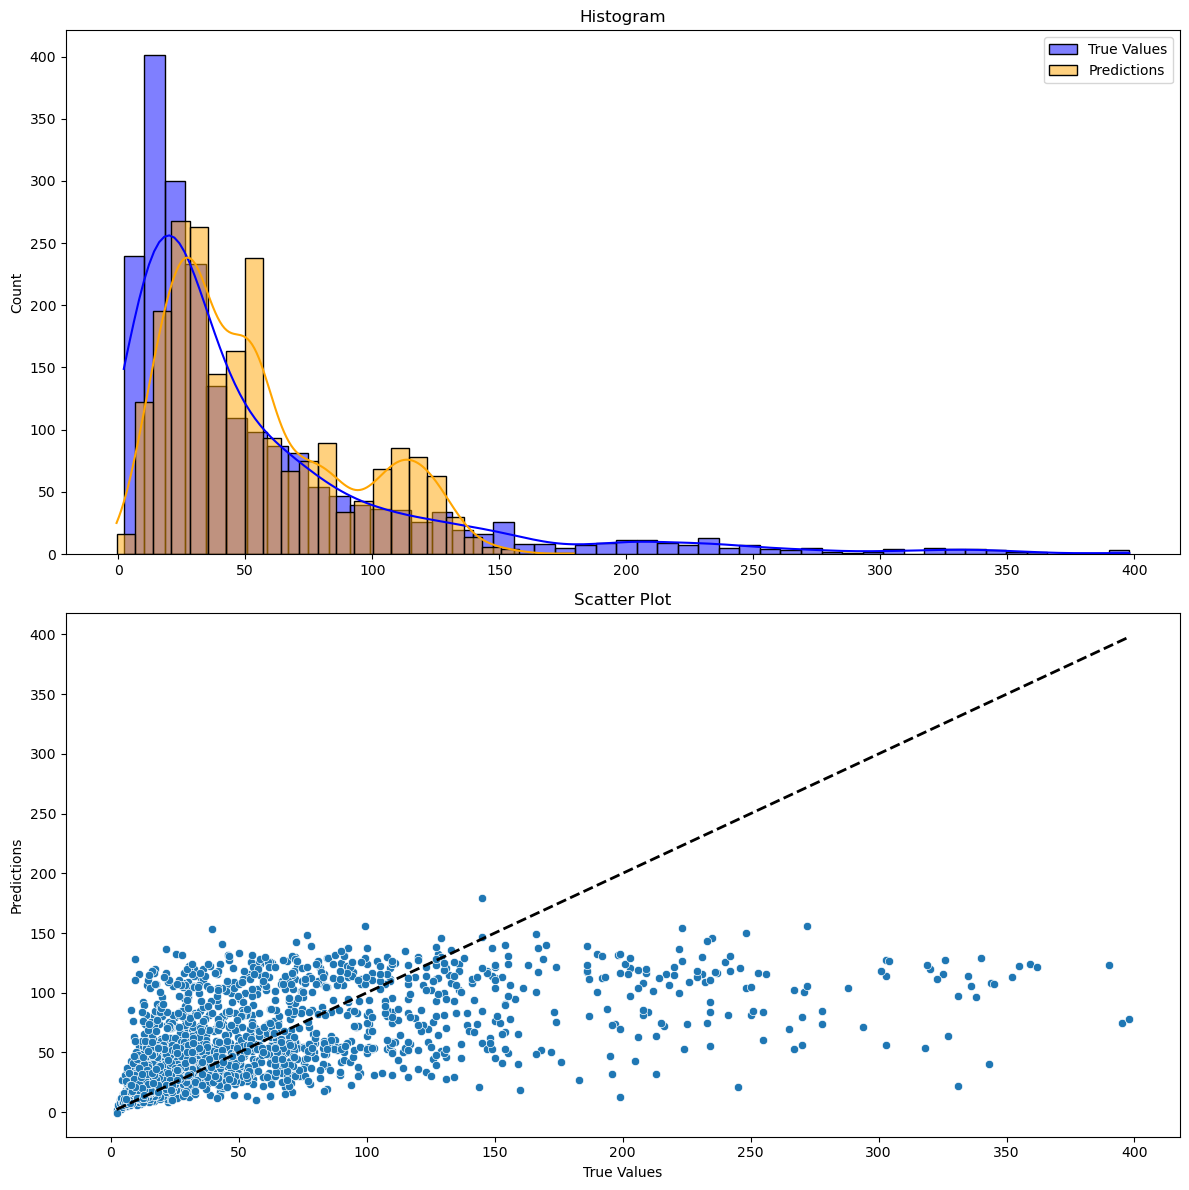

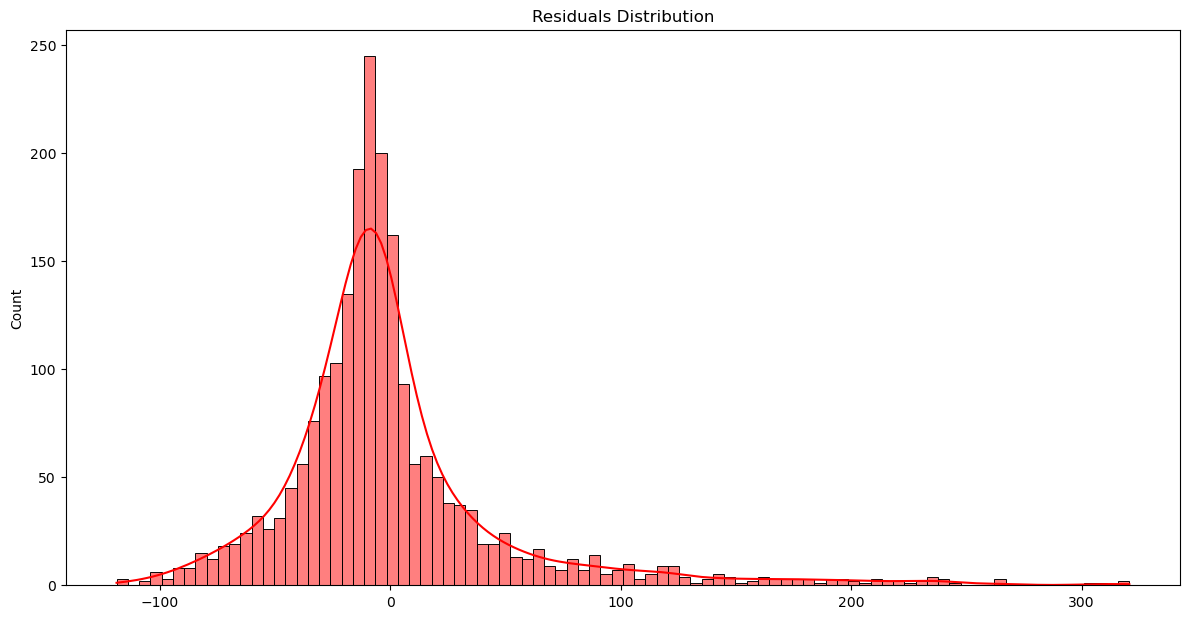

In [ ]:
analyze_predictions(true_values, predictions)

#### Error Anaylsis - Performance by percentiles - Test Set

In [ ]:
def analyze_predictions_by_percentiles(true_values, predictions, percentiles=[5, 25, 50, 75, 95, 100]):
    true_values = true_values.ravel()
    predictions = predictions.ravel()

    # Calculate residuals
    residuals = np.abs(true_values - predictions)

    # Combine true values, predictions, and residuals into a DataFrame
    df = pd.DataFrame({
        'True Values': true_values,
        'Predictions': predictions,
        'Residuals': residuals
    })

    # Calculate and print performance metrics for the specified percentiles
    performance_by_percentile = {}
    for percentile in percentiles:
        threshold = np.percentile(df['Residuals'], percentile)
        within_threshold = df[df['Residuals'] <= threshold]
        mae = mean_absolute_error(within_threshold['True Values'], within_threshold['Predictions'])
        mse = mean_squared_error(within_threshold['True Values'], within_threshold['Predictions'])
        rmse = np.sqrt(mse)
        r2 = r2_score(within_threshold['True Values'], within_threshold['Predictions'])

        performance_by_percentile[percentile] = {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        }

    # Print performance by percentile
    for percentile, metrics in performance_by_percentile.items():
        print(f"Performance for {percentile}th Percentile:")
        print(f"  Mean Absolute Error (MAE): {metrics['MAE']}")
        print(f"  Mean Squared Error (MSE): {metrics['MSE']}")
        print(f"  Root Mean Squared Error (RMSE): {metrics['RMSE']}")
        print(f"  R-squared (R²): {metrics['R2']}")
        print()

    return performance_by_percentile

In [ ]:
performance_by_percentile = analyze_predictions_by_percentiles(true_values, predictions)

Performance for 5th Percentile:
  Mean Absolute Error (MAE): 0.7474384263709739
  Mean Squared Error (MSE): 0.7239189828261403
  Root Mean Squared Error (RMSE): 0.8508342863484877
  R-squared (R²): 0.998928460688171

Performance for 25th Percentile:
  Mean Absolute Error (MAE): 3.8971015809641947
  Mean Squared Error (MSE): 20.793917058923384
  Root Mean Squared Error (RMSE): 4.560034765100304
  R-squared (R²): 0.9687461035193837

Performance for 50th Percentile:
  Mean Absolute Error (MAE): 8.355592154021616
  Mean Squared Error (MSE): 96.78240962073029
  Root Mean Squared Error (RMSE): 9.837805122115922
  R-squared (R²): 0.8790390132213095

Performance for 75th Percentile:
  Mean Absolute Error (MAE): 14.687571562175398
  Mean Squared Error (MSE): 324.88823929585186
  Root Mean Squared Error (RMSE): 18.02465642656891
  R-squared (R²): 0.6793406087058392

Performance for 95th Percentile:
  Mean Absolute Error (MAE): 24.56963645309268
  Mean Squared Error (MSE): 1117.778037251093
  Roo

In [ ]:
residuals = true_values - predictions

threshold = 2 * np.std(residuals)

outlier_indices = np.where(np.abs(residuals) > threshold)[0]

outliers = pd.DataFrame({
        'True Values': true_values[outlier_indices].flatten(),
        'Predictions': predictions[outlier_indices].flatten(),
        'Residuals': residuals[outlier_indices].flatten()})

outliers

,True Values,Predictions,Residuals
0,242.00000,118.03468,123.96532
1,187.00000,80.63280,106.36720
2,197.00000,73.59823,123.40177
3,240.00000,125.92532,114.07468
4,131.00000,27.82465,103.17535
...,...,...,...
108,205.00000,42.46789,162.53211
109,398.00000,77.98853,320.01147
110,270.00000,79.91240,190.08760
111,272.00000,105.24797,166.75203


#### Error Analysis - Distributions - Train Set

In [ ]:
true_values, predictions = evaluate_model(train_ds, best_model, return_values=True)

Mean Absolute Error: 31.090982066383436
Mean Squared Error: 2515.191066835643
Root Mean Squared Error: 50.15168059831737
y_true_mean: 56.63767857142857
y_true_std: 63.28535716511151


Basic Statistics:
                  count     mean      std     min      25%      50%      75%  \
True Values 5040.00000 56.63768 63.29164 2.30000 16.30000 29.70000 74.00000   
Predictions 5040.00000 54.82693 35.51150 0.40295 26.82223 46.06931 78.63992   

                  max  
True Values 399.00000  
Predictions 162.04836  

Mean Absolute Error (MAE):	31.090982066383436
Mean Squared Error (MSE):	2515.191066835643
Root Mean Squared Error (RMSE):	50.15168059831737
R-squared (R²):			0.3719929619007851


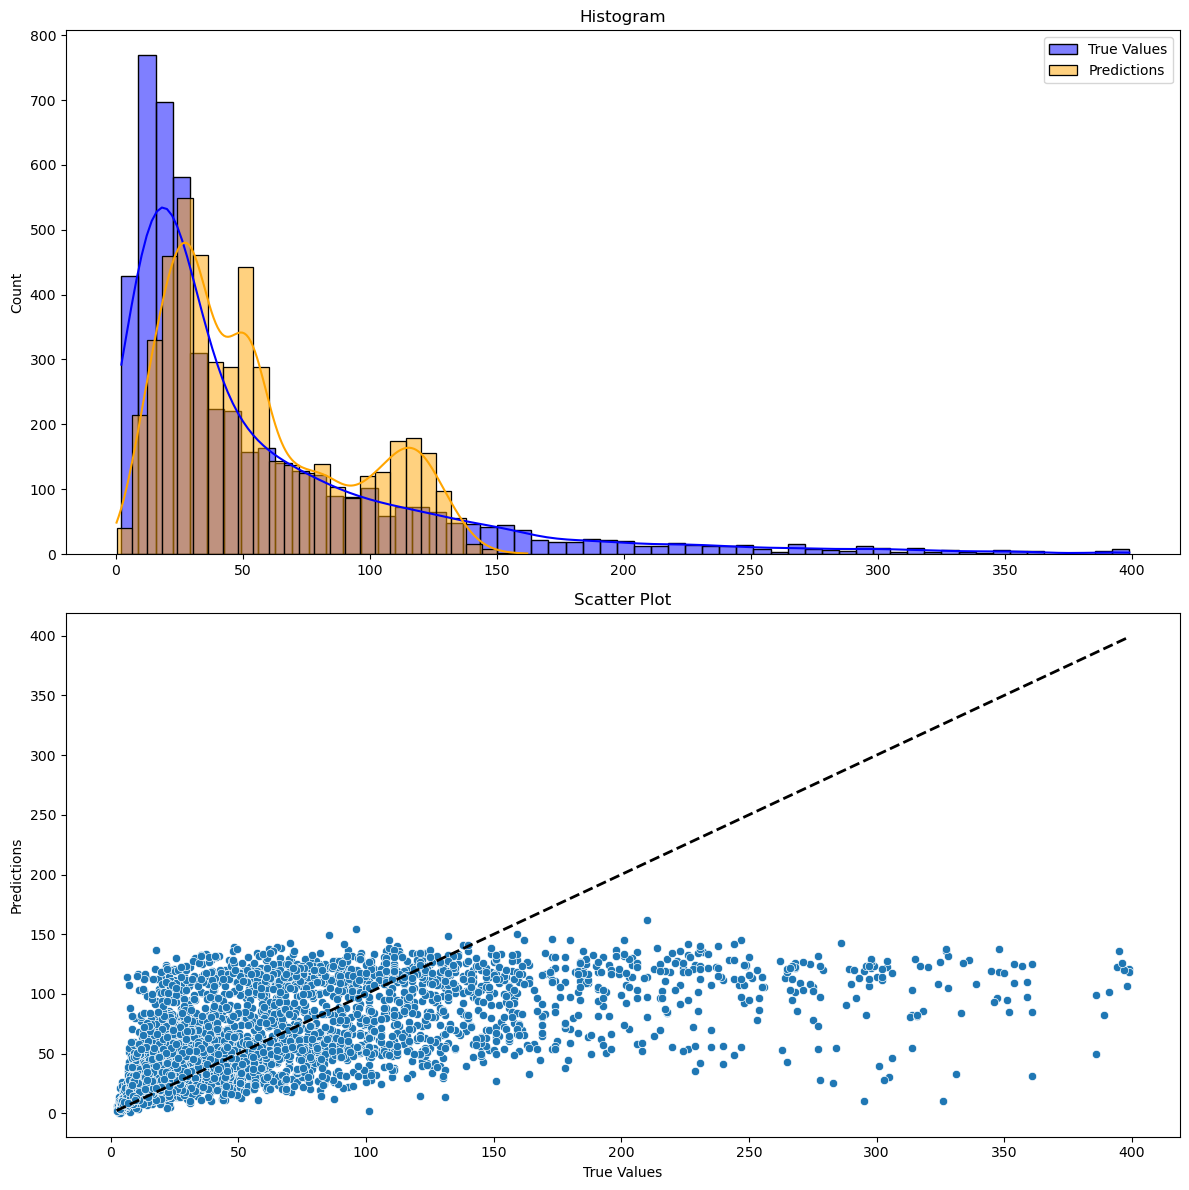

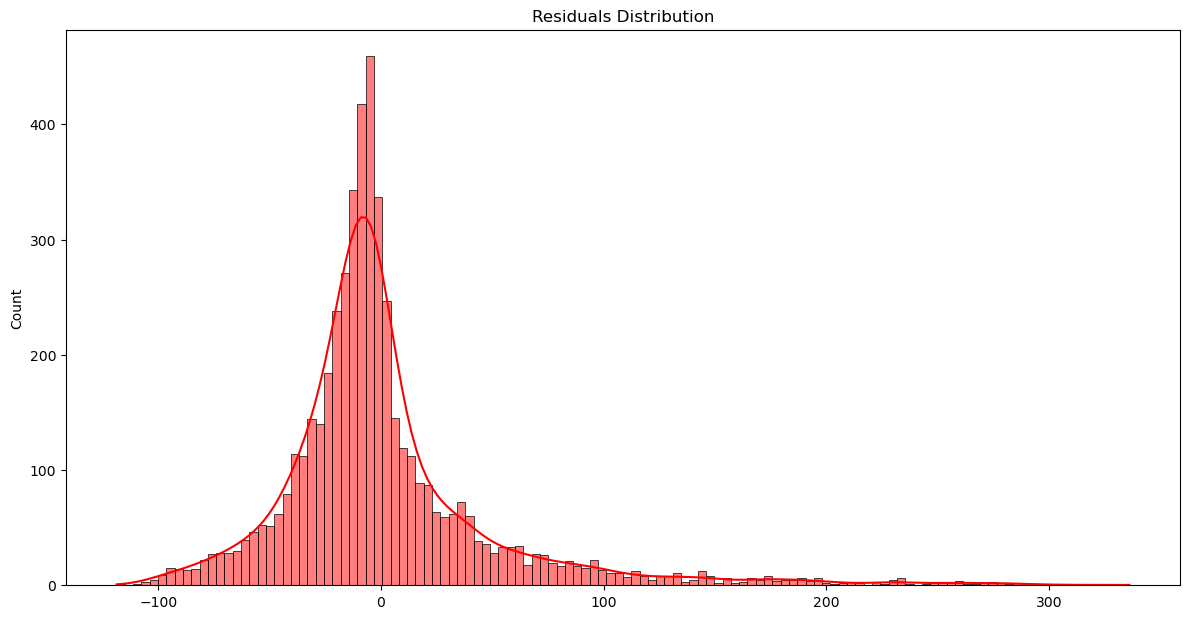

In [ ]:
analyze_predictions2(true_values, predictions)

#### Error Anaylsis - Performance by percentiles - Train Set

In [ ]:
performance_by_percentile = analyze_predictions_by_percentiles(true_values, predictions)

Performance for 5th Percentile:
  Mean Absolute Error (MAE): 0.8144761255809241
  Mean Squared Error (MSE): 0.8999642017732878
  Root Mean Squared Error (RMSE): 0.9486644305407934
  R-squared (R²): 0.9987047023704188

Performance for 25th Percentile:
  Mean Absolute Error (MAE): 3.803086966522157
  Mean Squared Error (MSE): 18.97195427693912
  Root Mean Squared Error (RMSE): 4.3556806904247605
  R-squared (R²): 0.9769396529639466

Performance for 50th Percentile:
  Mean Absolute Error (MAE): 8.085847128440463
  Mean Squared Error (MSE): 90.58600053211487
  Root Mean Squared Error (RMSE): 9.517667809506428
  R-squared (R²): 0.8985142616926172

Performance for 75th Percentile:
  Mean Absolute Error (MAE): 14.45458556729019
  Mean Squared Error (MSE): 319.2989137263372
  Root Mean Squared Error (RMSE): 17.868937117980387
  R-squared (R²): 0.7204751049770465

Performance for 95th Percentile:
  Mean Absolute Error (MAE): 24.136007924257164
  Mean Squared Error (MSE): 1078.8897524168262
  Ro

In [ ]:
residuals = true_values - predictions

threshold = 2 * np.std(residuals)

outlier_indices = np.where(np.abs(residuals) > threshold)[0]

outliers = pd.DataFrame({
        'True Values': true_values[outlier_indices].flatten(),
        'Predictions': predictions[outlier_indices].flatten(),
        'Residuals': residuals[outlier_indices].flatten()})

outliers

,True Values,Predictions,Residuals
0,354.00000,124.92052,229.07948
1,304.00000,122.52005,181.47995
2,348.00000,118.59805,229.40195
3,223.00000,107.73376,115.26624
4,229.00000,124.00620,104.99380
...,...,...,...
238,396.00000,125.99014,270.00986
239,361.00000,31.03887,329.96113
240,266.00000,103.27118,162.72882
241,361.00000,84.84697,276.15303


#### eXplainiable Artificial Intelligence (XAI)

In [ ]:
shap.initjs()

In [ ]:
print("\nSHAP analizi başlıyor...")

print(f"Modelin beklediği girdi boyutu: {best_model.input_shape}")
print(f"X_train boyutu: {X_train.shape}")
print(f"X_test boyutu: {X_test.shape}")

background_data = X_train.to_numpy().astype(np.float32)
explainer = shap.GradientExplainer(best_model, background_data)

print("SHAP değerleri hesaplanıyor... (Bu işlem biraz sürebilir)")
test_data_numpy = X_test.to_numpy().astype(np.float32)
shap_values = explainer.shap_values(test_data_numpy)


SHAP analizi başlıyor...
Modelin beklediği girdi boyutu: (None, 9)
X_train boyutu: (5040, 9)
X_test boyutu: (2160, 9)
SHAP değerleri hesaplanıyor... (Bu işlem biraz sürebilir)


In [ ]:
if isinstance(shap_values, list):
    shap_values = shap_values[0]

print(f"Orijinal SHAP değer boyutu: {shap_values.shape}")
shap_values_final = np.squeeze(shap_values)
print(f"Düzeltilmiş SHAP değer boyutu: {shap_values_final.shape}")

Orijinal SHAP değer boyutu: (2160, 9, 1)
Düzeltilmiş SHAP değer boyutu: (2160, 9)


In [ ]:
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "font.weight": "bold",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.3,
    "savefig.dpi": 600,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "grid.color": "white"
})

feature_names = X_test.columns.tolist()
mean_abs = np.abs(shap_values_final).mean(axis=0)


 Bar plot oluşturuluyor...


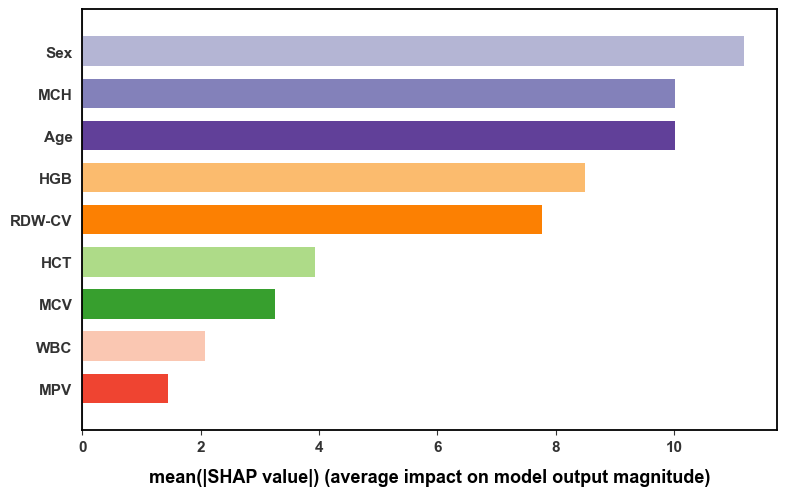

   SHAP_Bar_CustomPalette.png' kaydedildi.


In [ ]:
# ============================================================
# --- Figure : Global Feature Importance (Bar Plot) ---
# ============================================================
print("\n Bar plot oluşturuluyor...")

# Özelleştirilmiş renk paleti
custom_colors = [
    "#ef4431", "#fac7b2", "#379f2e", "#aedb88", "#fc8002", "#fbbb6e",
    "#614099", "#8381ba", "#b4b5d4", "#1862a9", "#4a95c6", "#93c2de",
    "#cedfef", "#b8191a"
]
color_cycle = itertools.cycle(custom_colors)  # renkleri döngüsel yap

# SHAP bar plot
shap.summary_plot(
    shap_values_final,
    X_test,
    feature_names=feature_names,
    plot_type="bar",
    max_display=25,
    show=False
)

# Bar renklerini uygula
ax = plt.gca()
patches = ax.patches
for patch, color in zip(patches, color_cycle):
    patch.set_facecolor(color)

# Başlık ve eksen stilleri
plt.title("", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)", fontsize=13, fontweight='bold', labelpad=10)
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

# Kenarlıklar
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.3)

plt.tight_layout()
plt.savefig("SHAP_Bar_CustomPalette.png", dpi=600, bbox_inches='tight')
plt.show()
print("   SHAP_Bar_CustomPalette.png' kaydedildi.")


Gradient violin plot oluşturuluyor...


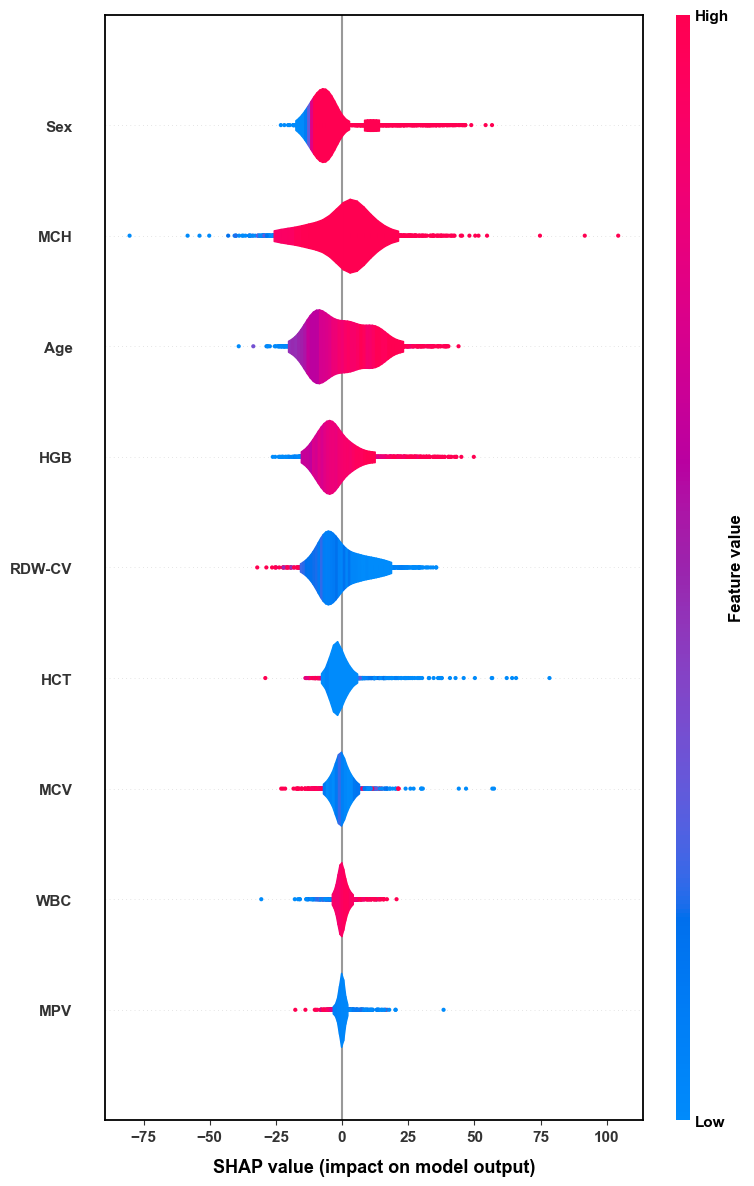

    'Figure_SHAP_Beeswarm_Gradient_Bold.png' kaydedildi.


In [ ]:
# ============================================================
# --- Figure : Gradient Violin Plot (Makale Stili) ---
# ============================================================
print("\nGradient violin plot oluşturuluyor...")

plt.figure(figsize=(8, 12))
shap.summary_plot(
    shap_values_final,
    X_test,
    feature_names=feature_names,
    show=False,
    plot_size=(8, 12),
    max_display=25,
    color_bar=True,
    plot_type='violin'  #  Gradient violin görünümü
)

plt.title("", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("SHAP value (impact on model output)", fontsize=13, fontweight='bold', labelpad=10)
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.3)

plt.tight_layout()
plt.savefig("Figure_SHAP_Beeswarm_Gradient_Bold.png", dpi=600, bbox_inches='tight')
plt.show()
print("    'Figure_SHAP_Beeswarm_Gradient_Bold.png' kaydedildi.")

In [ ]:
# ============================================================
# --- Mean(|SHAP|) Tablosu ---
# ============================================================
mean_abs_shap = np.abs(shap_values_final).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean|SHAP|': mean_abs_shap
}).sort_values(by='Mean|SHAP|', ascending=False)

print("\n--- SHAP Global Feature Importance ---")
print(shap_importance)
print("------------------------------------")

shap_importance.to_csv("SHAP_Global_Importance_Table.csv", index=False)
print("\n📄 'SHAP_Global_Importance_Table.csv' kaydedildi.")
print("\nTüm işlemler başarıyla tamamlandı ✅")


--- SHAP Global Feature Importance ---
  Feature  Mean|SHAP|
8     Sex    11.17629
6     MCH    10.01063
0     Age    10.00761
1     HGB     8.48515
7  RDW-CV     7.76677
3     HCT     3.93491
2     MCV     3.25316
4     WBC     2.07966
5     MPV     1.44753
------------------------------------

📄 'SHAP_Global_Importance_Table.csv' kaydedildi.

Tüm işlemler başarıyla tamamlandı ✅



Dependence plot'lar oluşturuluyor...
   En önemli 9 özellik için grafik oluşturulacak:
   ['Sex', 'MCH', 'Age', 'HGB', 'RDW-CV', 'HCT', 'MCV', 'WBC', 'MPV']
   - Sex için grafik oluşturuluyor...
Uyarı: Renk çubuğu stili ayarlanamadı. 'str' object has no attribute 'get_text'
     'SHAP_Dependence_Sex.png' kaydedildi.
   - MCH için grafik oluşturuluyor...
Uyarı: Renk çubuğu stili ayarlanamadı. 'str' object has no attribute 'get_text'
     'SHAP_Dependence_MCH.png' kaydedildi.
   - Age için grafik oluşturuluyor...
Uyarı: Renk çubuğu stili ayarlanamadı. 'str' object has no attribute 'get_text'
     'SHAP_Dependence_Age.png' kaydedildi.
   - HGB için grafik oluşturuluyor...
Uyarı: Renk çubuğu stili ayarlanamadı. 'str' object has no attribute 'get_text'
     'SHAP_Dependence_HGB.png' kaydedildi.
   - RDW-CV için grafik oluşturuluyor...
Uyarı: Renk çubuğu stili ayarlanamadı. 'str' object has no attribute 'get_text'
     'SHAP_Dependence_RDW-CV.png' kaydedildi.
   - HCT için grafik oluşturulu

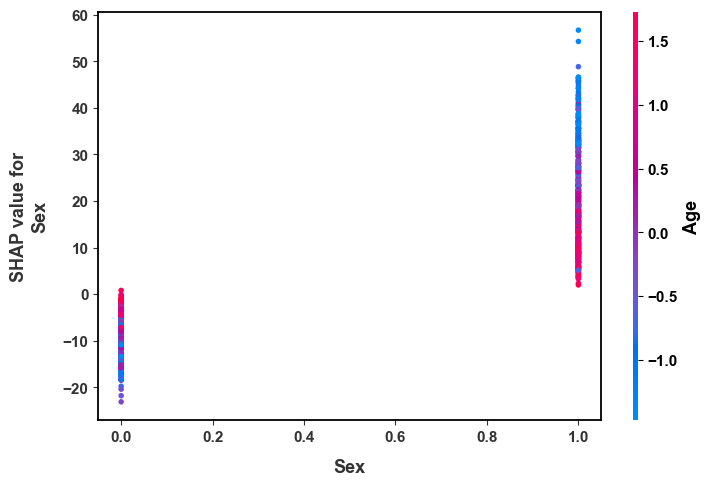

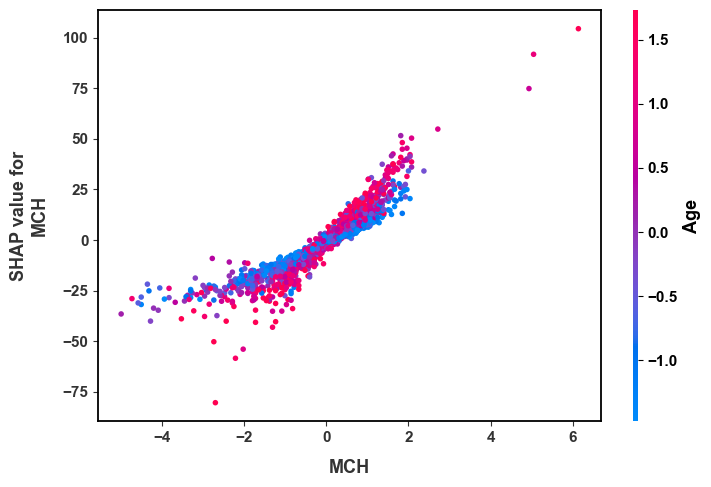

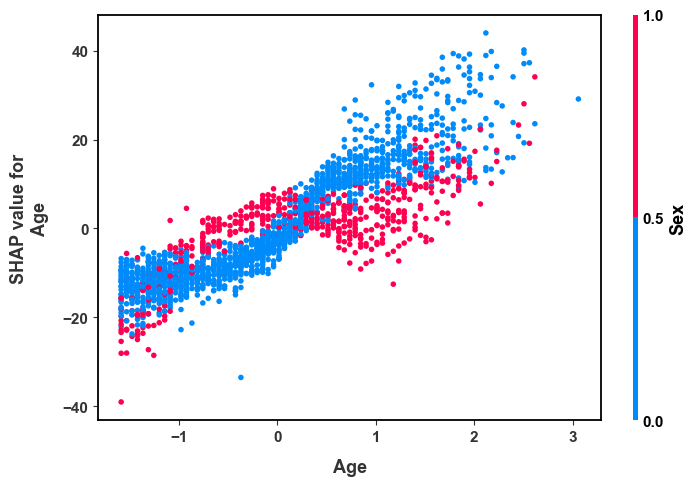

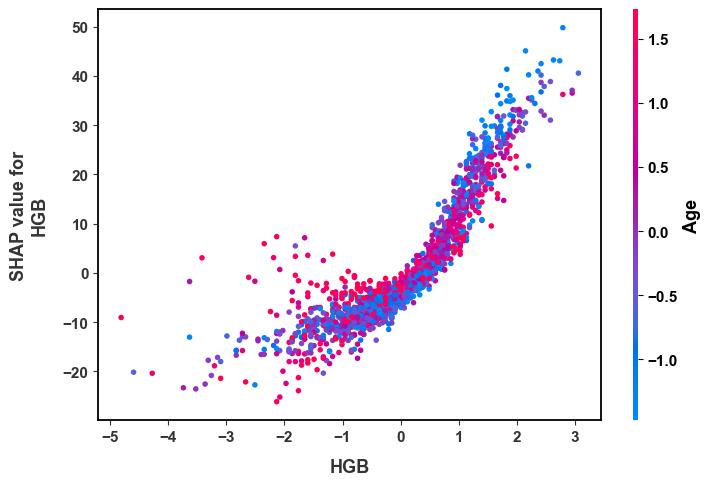

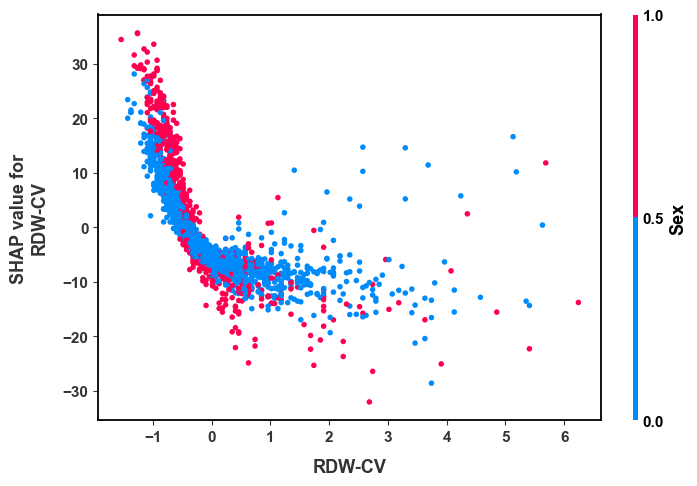

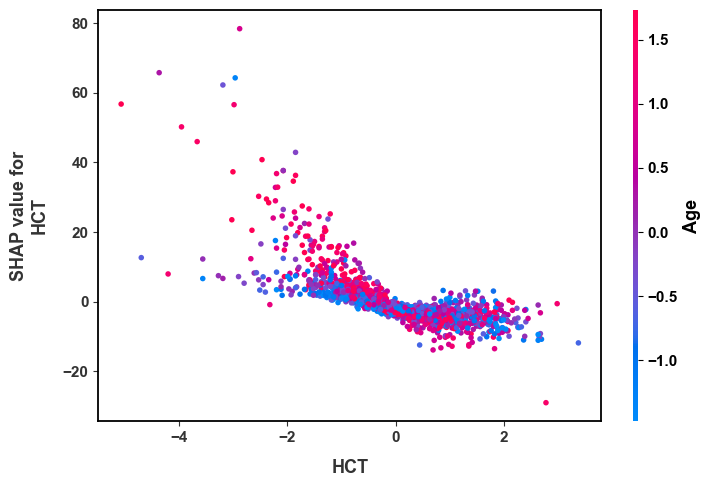

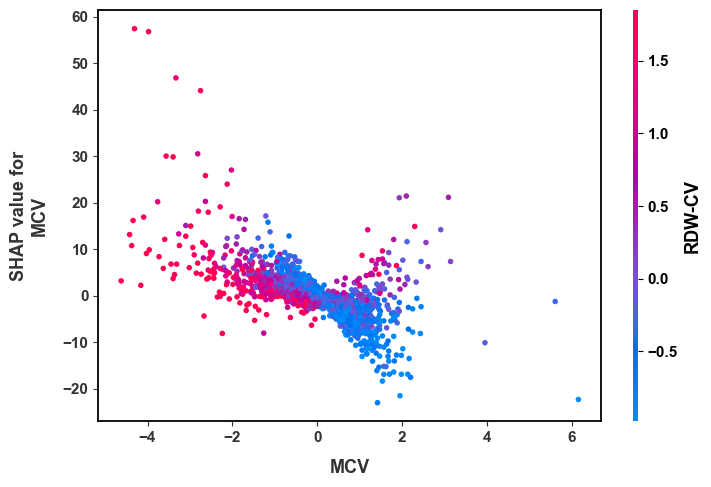

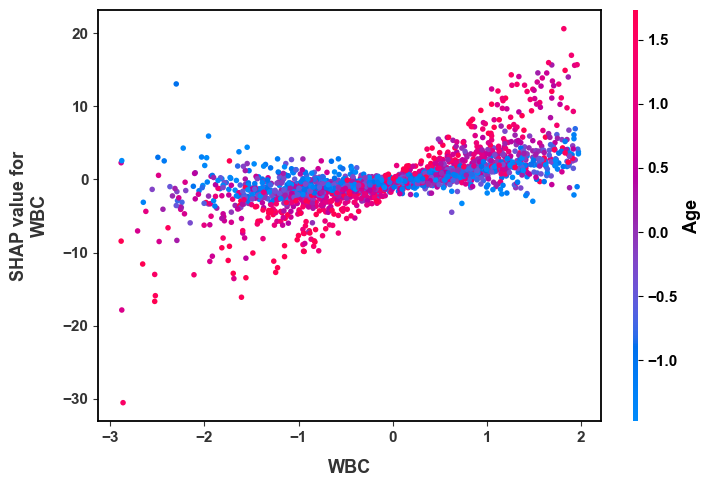

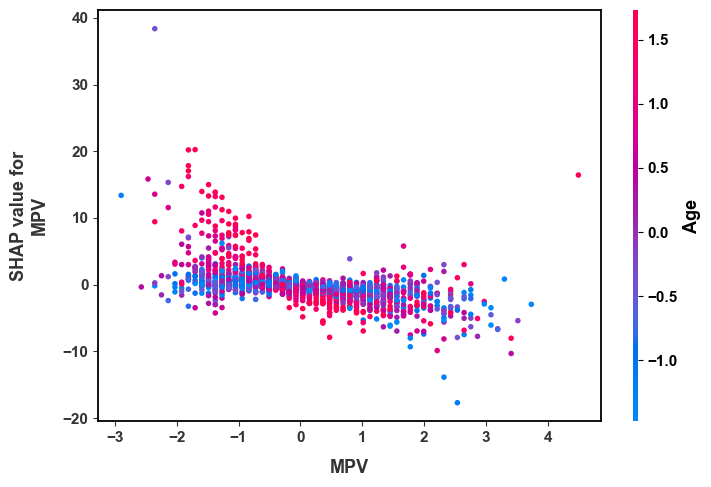

In [ ]:
# ============================================================
# --- Figure : Dependence Plots (Top 9 Features) ---
# ============================================================
print("\nDependence plot'lar oluşturuluyor...")

# 1. En önemli özellikleri belirle
# Ortalama mutlak SHAP değerlerine göre sırala
mean_abs_shap = np.abs(shap_values_final).mean(axis=0)
# En yüksekten en düşüğe doğru sıralanmış indeksleri al
sorted_indices = np.argsort(mean_abs_shap)[::-1]

# 2. En önemli N (örn: 9) özellik için döngü başlat
N_TOP_FEATURES = 9
top_features_indices = sorted_indices[:N_TOP_FEATURES]
top_features_names = [feature_names[i] for i in top_features_indices]

print(f"   En önemli {N_TOP_FEATURES} özellik için grafik oluşturulacak:")
print(f"   {top_features_names}")

for feature_name in top_features_names:
    print(f"   - {feature_name} için grafik oluşturuluyor...")

    # Her grafik için yeni bir figure oluştur
    fig = plt.figure()

    # SHAP dependence plot'u çizdir
    shap.dependence_plot(
        feature_name,
        shap_values_final,
        X_test,
        feature_names=feature_names,
        interaction_index="auto",  # En güçlü etkileşimi otomatik bul ve renklendir
        show=False
    )

    # 3. Grafik Stilini Özelleştir (Sizin stilinize uygun)
    ax = plt.gca()

    # Başlık ve eksenler
    # SHAP plot başlık eklediği için tekrar eklemeye gerek yok, ama fontunu ayarlayabiliriz
    ax.set_title(ax.get_title(), fontsize=16, fontweight='bold', pad=15)

    # X ve Y eksen etiketleri
    ax.set_xlabel(ax.get_xlabel(), fontsize=13, fontweight='bold', labelpad=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=13, fontweight='bold', labelpad=10)

    # Tick (çentik) fontları
    plt.xticks(fontsize=11, fontweight='bold')
    plt.yticks(fontsize=11, fontweight='bold')

    # Renk çubuğu (varsa) etiket fontu
    if ax.get_legend() is None and len(ax.collections) > 0:
        try:
            # SHAP'ın renk çubuğunu (colorbar) bul ve stil ver
            cb = plt.gcf().get_axes()[-1]
            cb.set_title(cb.get_title().get_text(), fontsize=12, fontweight='bold')
            cb.tick_params(labelsize=11)
        except Exception as e:
            print(f"Uyarı: Renk çubuğu stili ayarlanamadı. {e}")

    # Kenarlıklar
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.3)

    plt.tight_layout()

    # Kaydet ve kapat
    save_filename = f"SHAP_Dependence_{feature_name.replace(' ', '_')}.png"
    plt.savefig(save_filename, dpi=600, bbox_inches='tight')
    plt.close(fig)  # Hafızayı yönetmek için figürü kapat

    print(f"     '{save_filename}' kaydedildi.")

print("Tüm dependence plot'lar tamamlandı.")


Gelişmiş SHAP Heatmap plot oluşturuluyor...
⚠️ explainer.expected_value alınamadı, tahmin ortalaması kullanılacak: 'GradientExplainer' object has no attribute 'expected_value'
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step


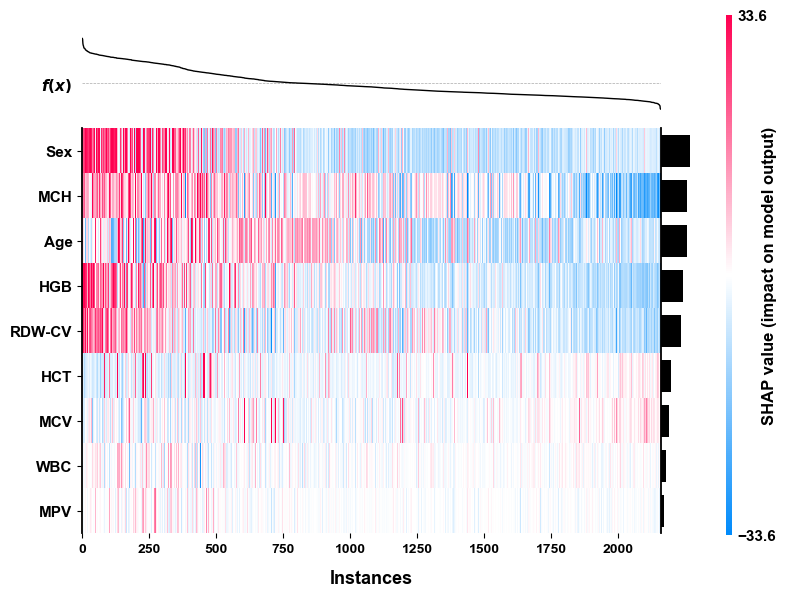

'Figure_SHAP_Advanced_Heatmap.png'başarıyla kaydedildi.


In [ ]:
# ============================================================
# --- Figure: Advanced SHAP Heatmap (Cohort-Level Analysis) ---
# ============================================================
print("\nGelişmiş SHAP Heatmap plot oluşturuluyor...")

# 1️⃣ Expected (base) value'yu güvenli biçimde al
try:
    expected_value = explainer.expected_value
    # Bazı modellerde bu bir dizi olur (örneğin [base_val])
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[0]
except Exception as e:
    print("⚠️ explainer.expected_value alınamadı, tahmin ortalaması kullanılacak:", e)
    expected_value = np.mean(best_model.predict(X_train.to_numpy().astype(np.float32)))

# 2️⃣ SHAP Explanation nesnesi oluştur
shap_explanation = shap.Explanation(
    values=shap_values_final,
    base_values=np.repeat(expected_value, shap_values_final.shape[0]),  # her örnek için base_value
    data=test_data_numpy,
    feature_names=feature_names
)

# 3️⃣ Figure oluştur
plt.figure(figsize=(12, 8))

# 4️⃣ SHAP Heatmap çizimi
shap.plots.heatmap(
    shap_explanation,
    max_display=25,
    instance_order=shap_explanation.sum(1),  # örnekleri model çıktısına göre sırala
    show=False
)

# 5️⃣ Estetik ve etiket düzenlemeleri
ax = plt.gca()
ax.set_title("", fontsize=16, fontweight='bold', pad=20)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.set_xlabel("Instances", fontsize=13, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.savefig("Figure_SHAP_Advanced_Heatmap.png", dpi=600, bbox_inches='tight')
plt.show()

print("'Figure_SHAP_Advanced_Heatmap.png'başarıyla kaydedildi.")

#### 5-fold CV

In [ ]:
random.seed(17)
np.random.seed(17)
tf.random.set_seed(17)

# NumPy dönüştürmeleri
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

# K-Fold ayarı
kfold = KFold(n_splits=5, shuffle=True, random_state=17)

# En iyi modeli seç
ann_model = random_search_tuner.get_best_models(num_models=1)[0]
#ann_model = load_model('ferritin_prediction_final_model.keras')

# Modelin başlangıç ağırlıklarını kaydet
initial_weights = ann_model.get_weights()

# Metrikler için boş listeler
cv_r2_scores = []
cv_rmse_scores = []
cv_mae_scores = []
cv_mse_scores = []

# K-Fold uygulama
for train_ix, test_ix in kfold.split(X_train):

    # Veriyi train/test olarak ayırma
    X_train_n, X_test_n = X_train[train_ix], X_train[test_ix]
    y_train_n, y_test_n = y_train[train_ix], y_train[test_ix]

    # Her fold için modelin ağırlıklarını sıfırlama (başlangıç ağırlıklarına döndür)
    ann_model.set_weights(initial_weights)

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True)

    # Modeli her fold için yeniden eğit
    ann_model.fit(X_train_n, y_train_n, epochs=25, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=0)

    # Test seti üzerinde tahmin yap
    test_pred = ann_model.predict(X_test_n).flatten()

    # Performans metriklerini hesapla
    r2score = r2_score(y_test_n, test_pred)  # R2
    mae_score = mean_absolute_error(y_test_n, test_pred)  # MAE
    mse_score = mean_squared_error(y_test_n, test_pred)  # MSE
    rmse_score = np.sqrt(mse_score)  # RMSE

    # Sonuçları kaydet
    cv_r2_scores.append(r2score)
    cv_mae_scores.append(mae_score)
    cv_rmse_scores.append(rmse_score)
    cv_mse_scores.append(mse_score)

# 5 fold sonuçlarının ortalamalarını ve standart sapmalarını hesapla
print("*********** ANN - Train Set (5-fold CV) ***********")
print("R-squared: {} \tStd: {}".format(np.mean(cv_r2_scores), np.std(cv_r2_scores)))
print("MAE: \t   {} \tStd: {}".format(np.mean(cv_mae_scores), np.std(cv_mae_scores)))
print("RMSE: \t   {} \tStd: {}".format(np.mean(cv_rmse_scores), np.std(cv_rmse_scores)))
print("MSE: \t   {} \tStd: {}".format(np.mean(cv_mse_scores), np.std(cv_mse_scores)))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
*********** ANN - Train Set (5-fold CV) ***********
R-squared: 0.36474067999628546 	Std: 0.014815220123832615
MAE: 	   30.823254083082787 	Std: 1.2338302188298296
RMSE: 	   50.36473516443026 	Std: 2.7939000688970568
MSE: 	   2544.412425778181 	Std: 276.82861185790557
